重新进行一下IRIS光谱的数据处理

In [2]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import os,cv2
from scipy.optimize import fmin
from scipy.ndimage import affine_transform
import shutil
from scipy.io import readsav
import glob
from matplotlib.patches import Rectangle
from scipy.ndimage import zoom

先处理一下OⅠ线，因为信号不够强，要整条狭缝积分，得到了高斯轮廓后再看是否有偏移

In [3]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[392],memmap=False)#对应时间21：04：35
rsm.info()
wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)

Filename: C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\iris_l2_20240618_163141_3602506433_raster_t000_r00392.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     347   ()      
  1                1 ImageHDU        33   (165, 778, 8)   int16 (rescales to float32)   
  2                1 ImageHDU        33   (203, 778, 8)   int16 (rescales to float32)   
  3                1 ImageHDU        33   (94, 778, 8)   int16 (rescales to float32)   
  4                1 ImageHDU        33   (165, 778, 8)   int16 (rescales to float32)   
  5                1 ImageHDU        33   (113, 778, 8)   int16 (rescales to float32)   
  6                1 ImageHDU        33   (145, 778, 8)   int16 (rescales to float32)   
  7                1 ImageHDU        33   (754, 778, 8)   int16 (rescales to float32)   
  8                1 ImageHDU        54   (47, 8)   float64   
  9                1 TableHDU        53  

拟合得到的多普勒速度为 39.37981607199615 km/s


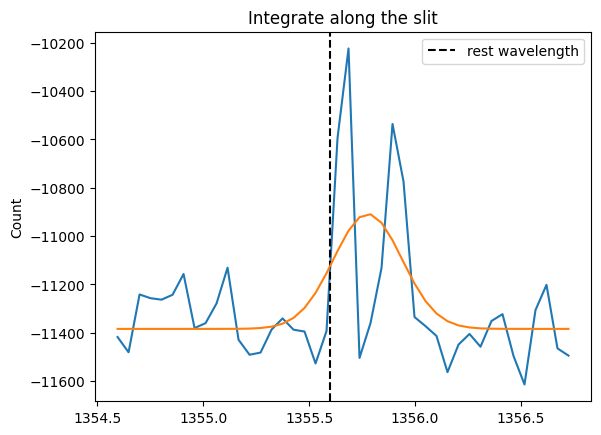

In [3]:
wave_y1=rsm[2].data[4,:,:].copy().sum(axis=0)
start_point,end_point=148,190
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point])
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest wavelength')
plt.ylabel('Count')
plt.title('Integrate along the slit')
plt.legend()
from gaussian_fit import fit_gaussian
result=fit_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point],center_guess=1355.66)
print('拟合得到的多普勒速度为',(result['center']-1355.599)/1355.599*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'])

1355.6617304385616
13.882520987761836 km/s


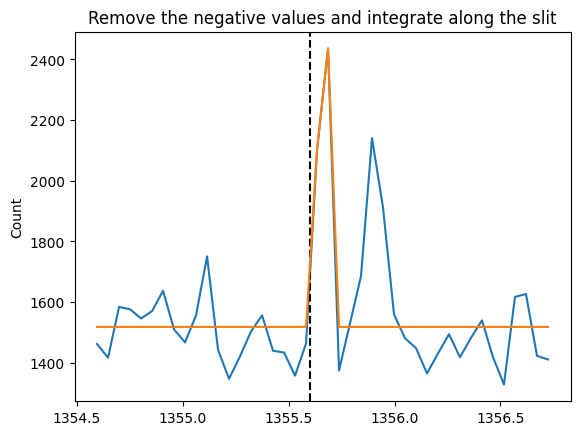

In [46]:
wave_y=rsm[2].data[4,:,:].copy()
wave_y[wave_y<0]=np.nan
#wave_y=np.nanmean(wave_y,axis=0)
wave_y=np.nansum(wave_y,axis=0)
start_point,end_point=148,190
plt.plot(wave_x[start_point:end_point],wave_y[start_point:end_point])
plt.axvline(x=1355.599,linestyle='--',color='black')
plt.ylabel('Count')
plt.title('Remove the negative values and integrate along the slit')

from gaussian_fit import fit_gaussian
result=fit_gaussian(wave_x[start_point:end_point],wave_y[start_point:end_point])
print(result['center'])
print((result['center']-1355.599)/1355.599*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'])

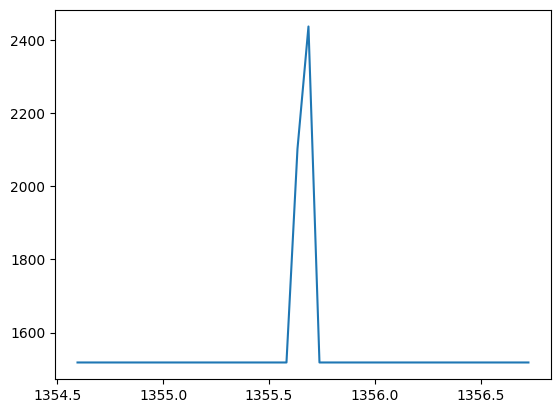

In [39]:
amp = result["amplitude"]
center = result["center"]
sigma = result["sigma"]
background = result["background"]
x=wave_x[start_point:end_point]
y_new = background + amp * np.exp(-0.5 * ((x - center) / sigma)**2)
plt.plot(x,y_new)

49.95484265856768 km/s


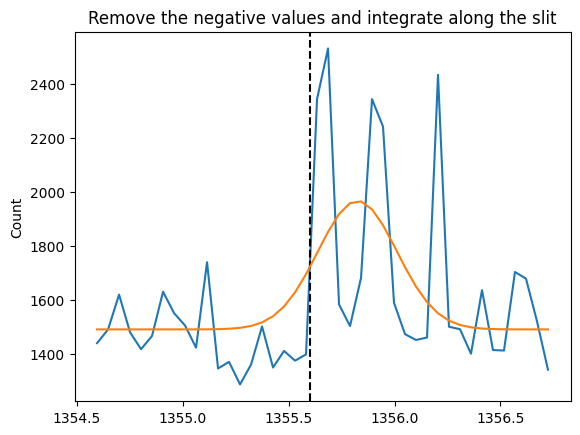

In [42]:
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[388],memmap=False)#对应时间21：04：35
wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)

wave_y=rsm[2].data[4,:,:].copy()
wave_y[wave_y<0]=np.nan
#wave_y=np.nanmean(wave_y,axis=0)
wave_y=np.nansum(wave_y,axis=0)
start_point,end_point=148,190
plt.plot(wave_x[start_point:end_point],wave_y[start_point:end_point])
plt.axvline(x=1355.599,linestyle='--',color='black')
plt.ylabel('Count')
plt.title('Remove the negative values and integrate along the slit')

from gaussian_fit import fit_gaussian
result=fit_gaussian(wave_x[start_point:end_point],wave_y[start_point:end_point])
print((result['center']-1355.599)/1355.599*3e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'])

In [4]:
#--------------------重新处理一下数据--------------------------------------------
rsm_1400=fits.open(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_SJI_1400_t000.fits')

8.714526 0.0


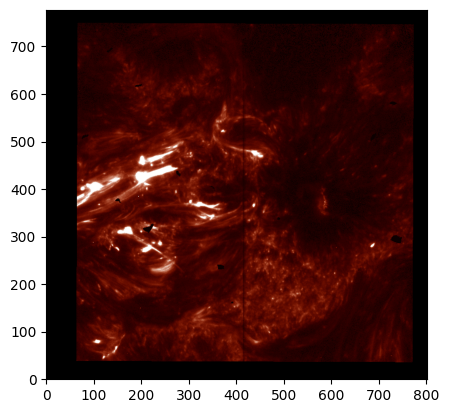

In [5]:
sji1400=rsm_1400[0].data
new_map=np.log(sji1400[727,:,:]+201)#对应时间21：04：35
print(new_map.max(),new_map.min())
plt.imshow(new_map,origin='lower',cmap='irissji1400',vmin=5.3,vmax=5.8)

1355.6590325666937
拟合得到的多普勒速度为 13.272184649083114 km/s


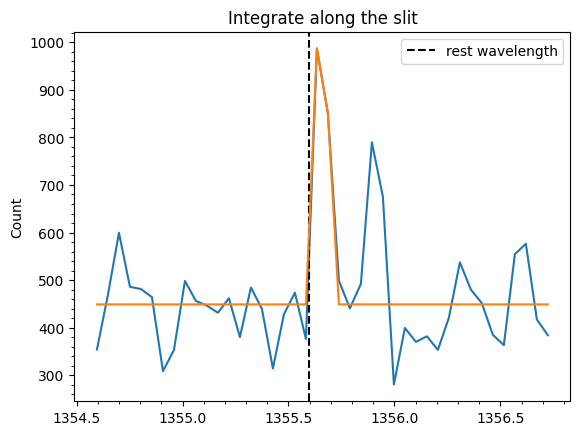

In [14]:
#根据上图，我只选取100-300的位置用来积分OⅠ光谱
file_list=glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm=fits.open(file_list[361],memmap=False)#对应时间21：04：35
wave_x=np.arange(1346.915,1346.915+203*0.0519,0.0519)

wave_y1=(np.vstack((rsm[2].data[4,100:300,:].copy(),rsm[2].data[4,550:700,:].copy()))).sum(axis=0)
start_point,end_point=148,190
plt.plot(wave_x[start_point:end_point],wave_y1[start_point:end_point])
plt.axvline(x=1355.599,linestyle='--',color='black',label='rest wavelength')
plt.ylabel('Count')
plt.title('Integrate along the slit')
plt.minorticks_on()
plt.legend()
from gaussian_fit import fit_gaussian
result=fit_gaussian(wave_x[start_point:end_point],wave_y1[start_point:end_point],center_guess=1355.66)
print(result['center'])
print('拟合得到的多普勒速度为',(result['center']-1355.599)/1355.599*2.997e5,'km/s')
plt.plot(wave_x[start_point:end_point],result['yfit'])

13.291022768778678
拟合得到的多普勒速度为 13.291022768778678 km/s


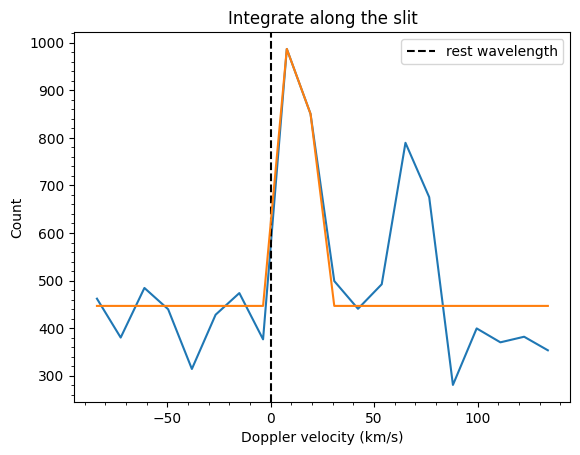

In [16]:
# 根据上图，我只选取100-300的位置用来积分OⅠ光谱
file_list = glob.glob(r'C:\Learning\PHD1st\magnetic_reconnecion\data\IRIS\iris_l2_20240618_163141_3602506433_raster\*.fits')
rsm = fits.open(file_list[361], memmap=False)  # 对应时间21：04：35

wave_x = np.arange(1346.915, 1346.915 + 203 * 0.0519, 0.0519)

rest_wave = 1355.599
c_kms = 2.997e5
vel_x = (wave_x - rest_wave) / rest_wave * c_kms

wave_y1 = (
    np.vstack((
        rsm[2].data[4, 100:300, :].copy(),
        rsm[2].data[4, 550:700, :].copy()
    ))
).sum(axis=0)

start_point, end_point = 160, 180

plt.plot(vel_x[start_point:end_point], wave_y1[start_point:end_point])
plt.axvline(x=0, linestyle='--', color='black', label='rest wavelength')

plt.xlabel('Doppler velocity (km/s)')
plt.ylabel('Count')
plt.title('Integrate along the slit')
plt.minorticks_on()
plt.legend()

from gaussian_fit import fit_gaussian

center_guess_wave = 1355.66
center_guess_vel = (center_guess_wave - rest_wave) / rest_wave * c_kms

result = fit_gaussian(
    vel_x[start_point:end_point],
    wave_y1[start_point:end_point],
    center_guess=center_guess_vel
)

print(result['center'])
print('拟合得到的多普勒速度为', result['center'], 'km/s')

plt.plot(vel_x[start_point:end_point], result['yfit'])

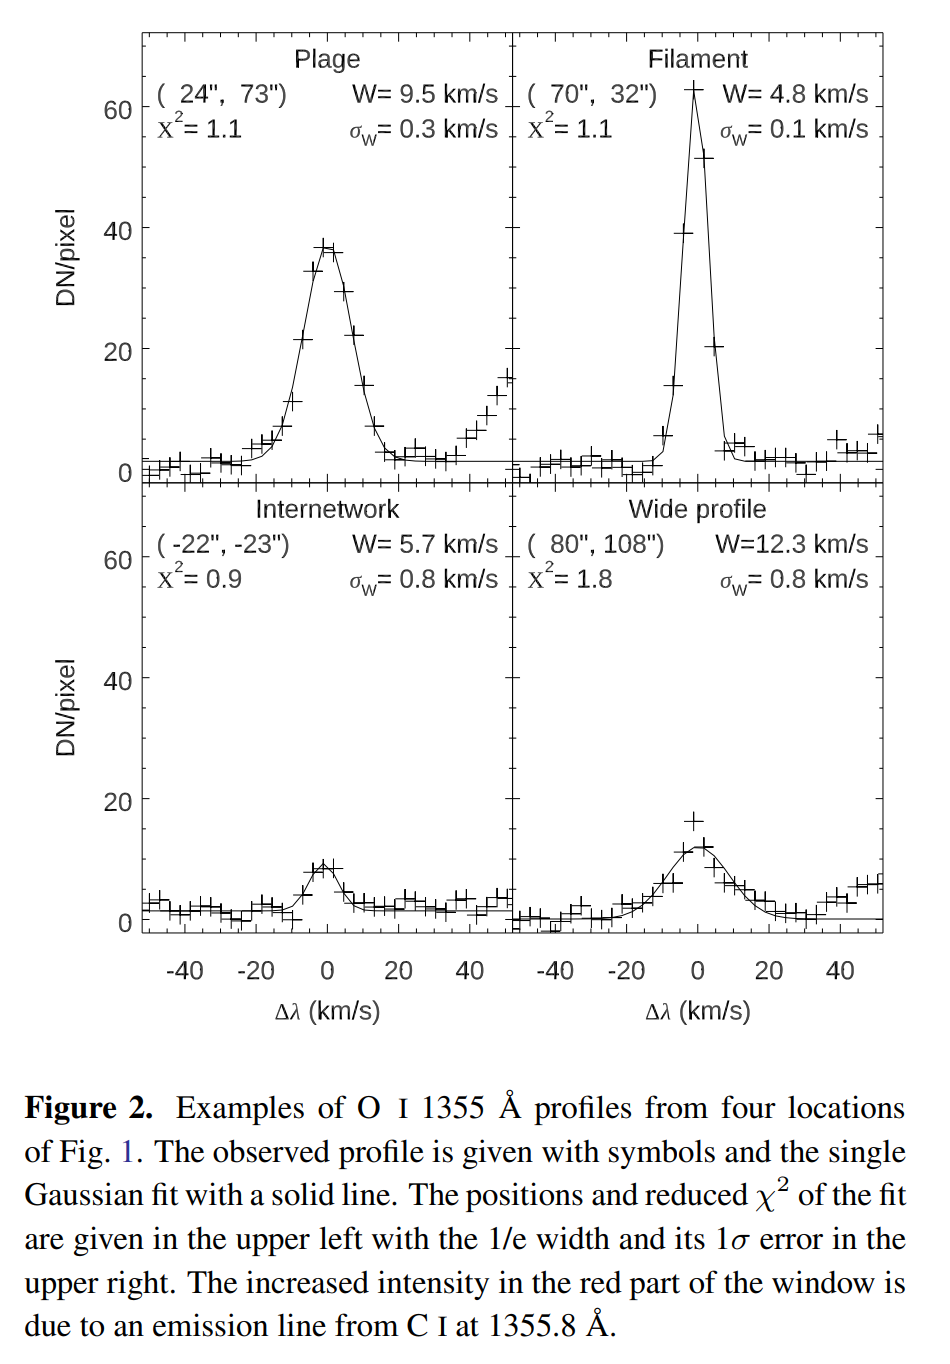  
来自文章An optically thin view of the solar chromosphere from observations of the O I 1355A spectral line  
我感觉差不多其实

这回看起来挺好的了

In [ ]:
#接下来开始处理Si Ⅳ的数据
#主要需要处理的就是信噪比的问题